In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import spikeinterface.full as si
from spikeinterface.sortingcomponents.motion import estimate_motion, interpolate_motion
from spikeinterface.widgets import plot_motion, plot_traces
from spikeinterface.preprocessing import get_motion_parameters_preset, get_motion_presets

from spikeinterface.sortingcomponents.peak_detection import detect_peaks
from spikeinterface.sortingcomponents.peak_selection import select_peaks
from spikeinterface.sortingcomponents.peak_localization import localize_peaks
from spikeinterface.sortingcomponents.motion import estimate_motion, interpolate_motion

from scipy.signal import welch
# %matplotlib widget


Overall, the idea of this is to walk through the steps that happen with Neuropixels data from collection to packaging into shareable format with metadata. 

Each of these steps forces the experimenter to make a decision (e.g., whether or not to execute a step, what parameters are used, labels) that necessarily affect what the downstream data and analyses. This notebook will contain an example recording for practical steps through this, as well as some discussion of what effect each choice might have. 

# 0. Raw Neuropixels Data

### Data Structure


**Neuropixels 1.0**: two raw data bands, one for "spikes" called the AP band filtered (hardware filtered on the Neuropixels base) 300 - 10000Hz and one for local field potentials called LFP band filtered (again, hardware filtered) 0.5 - 1000 Hz. These two bands are separately amplified and digitized, and sampled at different rates: AP band at 30kHz, LFP band at 2.5kHz. The two bands produce two separate data files, which will be named different things depending the recording system used. 
<br>
<br>
**Neuropixels 2.0**: one raw data file, broadband, sampled at 30kHz. 



There are two available acquisition programs, Open Ephys GUI and SpikeGLX. Both save the raw data in a similar format, but with a different name and in an different folder structure.
<br>
<br>
**Open Ephys** folder with one Neuropixels 1.0:
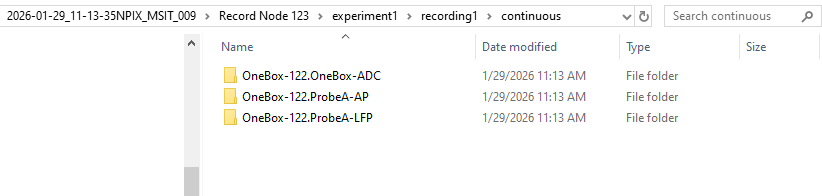
Multiple probes will each have their own folder _for each band_. 
<br>
the raw data for each band (if multiple) are stored .dat files in each band folder:
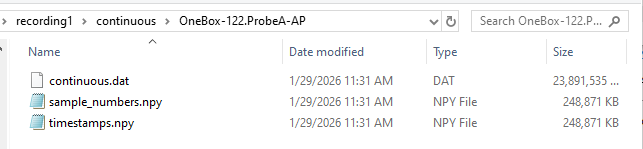

**Spike GLX** folder with three Neuropixels 1.0:
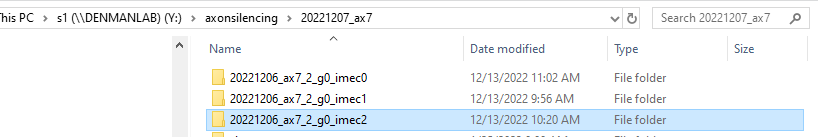
<br>
the raw data for each band (if multiple) are stored .bin files in the probe folder:
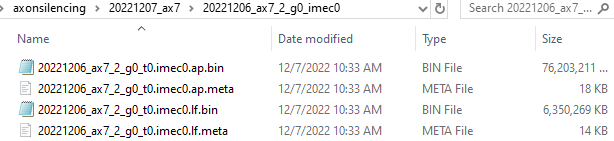

The raw data are a one-dimensional flat binary file, where `N = number of channels` and `M=number of time samples` the size is `1 x N*M` and the order is `ch0t0,ch1t0,...,chNt0,ch0t1,ch1,t1,...,chNtM`

### Load Data


You can read this raw data in several ways, including using some wrappers from packages. At the base though, there are two options: (1) read all of the data from disk in to memory at once. This means you need as much RAM as the size of the recording. (2) memory map the raw data, which is enable "lazy loading" where instead of loading the whole thing in to memory at once you only load data from disk to RAM when it is used. 

Generally (2), memory mapping, is preferrable for raw data to manage RAM usage

In [2]:
# the dataset has been locally downloaded
base_folder = Path(r'G:\MSIT\NPIX_MSIT_009\2026-01-29_11-13-35NPIX_MSIT_009')
np_data = base_folder / 'Record Node 123/experiment1/recording1/'

In [3]:
mmap = np.memmap(np_data / 'continuous'/ 'OneBox-122.ProbeA-AP' / 'continuous.dat', dtype='int16', mode='r')

In [4]:
mmap.shape

(12232465920,)

Most APIs have loaders that wrap around memmap to lazy load raw data for later use. 

In [5]:
raw_rec_AP = si.read_openephys(np_data,stream_name = 'Record Node 123#OneBox-122.ProbeA-AP')#.read_spikeglx(np_data_drift)
print(raw_rec_AP)
raw_rec_LFP = si.read_openephys(np_data,stream_name = 'Record Node 123#OneBox-122.ProbeA-LFP')#.read_spikeglx(np_data_drift)
print(raw_rec_LFP)

OpenEphysBinaryRecordingExtractor: 384 channels - 30.0kHz - 1 segments - 31,855,380 samples 
                                   1,061.85s (17.70 minutes) - int16 dtype - 22.78 GiB
OpenEphysBinaryRecordingExtractor: 384 channels - 2500.0Hz - 1 segments - 2,654,615 samples 
                                   1,061.85s (17.70 minutes) - int16 dtype - 1.90 GiB


# 1. Preprocessing 

All of these "preprocessing" steps are meant to change the underlying data, instead of derive something new from it (as spike detection is, for example). That said, each can be applied to the raw data but return a copy. This workflow, where the outputs of each step do not replace the input data, allows for more easy roll back to earlier processing steps. 

## a. filtering

there are many reasons to filter the data:
1. The Neuropixels 1.0 hardware filters are 1st order, and you can filter more aggressively offline
2. remove non-biological signal: line noise (60 Hz and multiples for us).
3. remove non-biological signal: high-frequency, often digital, noise 

In [6]:
AP_high = si.bandpass_filter(raw_rec_AP, freq_min=300, freq_max=3000, margin_ms=2)

c:\Anaconda3\envs\spikeinterface\Lib\site-packages\spikeinterface\preprocessing\filter.py:513: UserWarning: The provided margin_ms (2 ms) is smaller than the recommended margin for the given freq_min (300 Hz). This may lead to artifacts at the edges of chunks during processing. Consider increasing the margin_ms to at least 16.666666666666668 ms.
  warnings.warn(


## b. phase correction

We noted above that the channels (in the AP for 1.0) are sampled at 30kHz, so every 33µS. But each channel does not have its own analog-to-digital converter, so data from multiple channels need to be temporally multiplexed to the same ADC _within_ a 33µS sample. There are 32 ADCs for Neuropixels 1.0 (24 for Neuropixels 2.0). Importantly, if there is a common signal across channels that are temporally multiplexed (such as a common noise), and that signal is faster than 30kHz, it will change within one sample. In this case, if you try to use the correlation of the same signal across channels (for examples, to remove the noise), the signal no longer be correlated. 
<br>
<br>
There are multiple ways to do deal with this (Open Ephys Neuropixels CAR only averages channels that are simultaneously sampled across the 32 ADCs. So 32 separate CARs of the 12 channels that each CAR samples). Another way to deal this is "phase correction", a.k.a. "destriping", a.k.a "global demux". These are all approaches to resampling 

In [7]:
AP_phasecorrected = si.phase_shift(recording=AP_high)  # phase correct the recording

## c. common noise removal

In [8]:
AP_CAR = si.common_reference(recording=AP_phasecorrected) # subtract the median

## a1. filter specific artifacts

In [10]:
fs = AP_CAR.get_sampling_frequency()
n_frames = int(60 * fs)
traces = AP_CAR.get_traces(start_frame=0, end_frame=n_frames) # shape: (time, channels)


In [11]:
f_raw, px_raw= welch(raw_rec_AP.get_traces(start_frame=0, end_frame=n_frames),fs=fs,nperseg=4096,noverlap=2048,detrend="constant",scaling="density",axis=0)
f_high, px_high= welch(AP_high.get_traces(start_frame=0, end_frame=n_frames),fs=fs,nperseg=4096,noverlap=2048,detrend="constant",scaling="density",axis=0)
f_CAR, px_CAR= welch(AP_CAR.get_traces(start_frame=0, end_frame=n_frames),fs=fs,nperseg=4096,noverlap=2048,detrend="constant",scaling="density",axis=0)

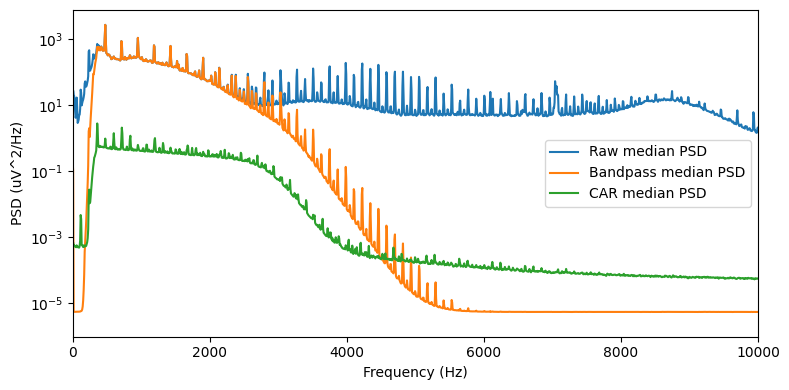

In [12]:
median_raw = np.median(px_raw, axis=1)
median_high = np.median(px_high, axis=1)
median_car = np.median(px_CAR, axis=1)

plt.figure(figsize=(8, 4))
plt.semilogy(f_raw, median_raw, label="Raw median PSD")
plt.semilogy(f_high, median_high, label="Bandpass median PSD")
plt.semilogy(f_CAR, median_car, label="CAR median PSD")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (uV^2/Hz)")
plt.xlim(0, 10000)  # adjust for AP/LFP context
plt.legend()
plt.tight_layout()
plt.show()

Detected notch freqs (Hz): [ 476.07  952.15 1428.22 1904.3  2380.37 2556.15 2797.85 2915.04 3032.23
 3149.41 3273.93 3391.11 3508.3  3750.   3867.19 3984.38 4101.56 4226.07
 4343.26 4460.45 4577.64 4702.15 4819.34 4936.52 5053.71 5295.41]


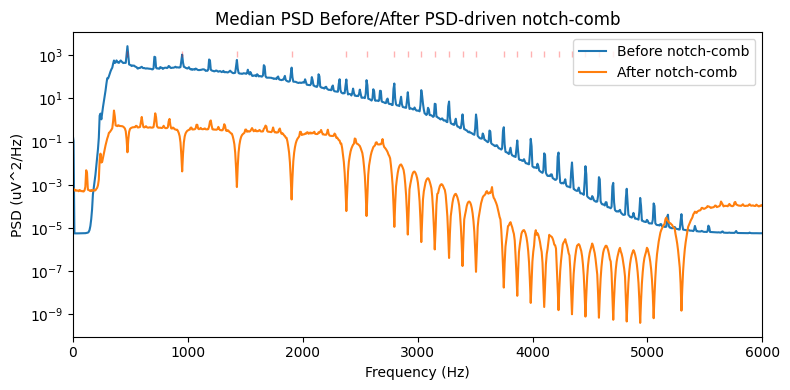

In [14]:
# Build and apply a PSD-driven notch-comb filter from AP_CAR
# Requires: AP_CAR already defined
from scipy.signal import welch, find_peaks, iirnotch, tf2sos, sosfiltfilt

f=f_high
median_psd = median_high #np.median(pxx, axis=1)
log_psd = 10 * np.log10(median_psd + 1e-20)

# 3) Detect narrow spectral spikes
freq_res = f[1] - f[0]
peaks, props = find_peaks(
    log_psd,
    prominence=6.0,                          # tune 3-10 dB
    distance=max(1, int(40 / freq_res)),     # >=40 Hz separation
)
peak_freqs = f[peaks]
peak_freqs = peak_freqs[(peak_freqs >= 50) & (peak_freqs <= 6000)]

print("Detected notch freqs (Hz):", np.round(peak_freqs, 2))

# 4) Create notch bank (comb-like if harmonically spaced)
Q = 30.0  # higher = narrower notches
sos_bank = []
for f0 in peak_freqs:
    if 0 < f0 < fs / 2:
        b, a = iirnotch(w0=f0, Q=Q, fs=fs)
        sos_bank.append(tf2sos(b, a))

tr = AP_CAR.get_traces(start_frame=0, end_frame=n_frames)  # (time, channels)

if sos_bank:
    sos = np.vstack(sos_bank)
    tr_clean = sosfiltfilt(sos, tr, axis=0)
else:
    tr_clean = tr.copy()

# 5) Compare before/after median PSD
f2, pxx2 = welch(
    tr_clean,
    fs=fs,
    nperseg=4096,
    noverlap=2048,
    detrend="constant",
    scaling="density",
    axis=0,
)
median_psd_clean = np.median(pxx2, axis=1)

plt.figure(figsize=(8, 4))
plt.semilogy(f, median_psd, label="Before notch-comb")
plt.semilogy(f2, median_psd_clean, label="After notch-comb")
if len(peak_freqs) > 0:
    y_top = np.nanmax(median_psd)
    plt.vlines(peak_freqs, y_top * 0.3, y_top * 0.6, colors="r", alpha=0.3, linewidth=1)

plt.xlim(0, 6000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (uV^2/Hz)")
plt.title("Median PSD Before/After PSD-driven notch-comb")
plt.legend()
plt.tight_layout()
plt.show()

## d. motion correction 

### motion estimation

In [15]:
raw_lfp = si.read_openephys(np_data,stream_name = 'Record Node 123#OneBox-122.ProbeA-LFP')#.read_spikeglx(np_data_drift)
print(raw_lfp)

OpenEphysBinaryRecordingExtractor: 384 channels - 2500.0Hz - 1 segments - 2,654,615 samples 
                                   1,061.85s (17.70 minutes) - int16 dtype - 1.90 GiB


In [16]:
lfprec_filtered = si.bandpass_filter(
    recording=raw_lfp,
    freq_min=0.5,
    freq_max=250,
    margin_ms=8000.,
    filter_order=3,
    dtype="float32",
    add_reflect_padding=True,
    ignore_low_freq_error=True,
)

c:\Anaconda3\envs\spikeinterface\Lib\site-packages\spikeinterface\preprocessing\filter.py:513: UserWarning: The provided margin_ms (8000.0 ms) is smaller than the recommended margin for the given freq_min (0.5 Hz). This may lead to artifacts at the edges of chunks during processing. Consider increasing the margin_ms to at least 10000.0 ms.
  warnings.warn(
c:\Anaconda3\envs\spikeinterface\Lib\site-packages\spikeinterface\preprocessing\filter.py:122: UserWarning: The margin size (20000 samples) is more than 20% of the global chunk size 2500 samples. This may lead to performance bottlenecks when chunking. Consider increasing the chunk_size or chunk_duration to minimize margin overhead.
  warnings.warn(


In [17]:
lfprec_deriv = si.directional_derivative(lfprec_filtered, order=2, edge_order=1)
lfprec_deriv = si.average_across_direction(lfprec_deriv)
lfprec_deriv = si.resample(lfprec_deriv, resample_rate=250, margin_ms=1000)

In [20]:
motion_folder = base_folder / 'motion_DREDGE_LFP/'
motion_nonrigid = estimate_motion(lfprec_deriv, method='dredge_lfp', rigid=False, progress_bar=True)
motion_nonrigid.save(motion_folder)
motion_nonrigid

Online chunks [10.0s each]:   0%|          | 0/106 [00:00<?, ?it/s]

FileExistsError: [WinError 183] Cannot create a file when that file already exists: 'G:\\MSIT\\NPIX_MSIT_009\\2026-01-29_11-13-35NPIX_MSIT_009\\motion_DREDGE_LFP'

In [19]:
motion_nonrigid = si.load_motion_info(motion_folder)
motion_nonrigid

FileNotFoundError: [Errno 2] No such file or directory: 'G:\\MSIT\\NPIX_MSIT_009\\2026-01-29_11-13-35NPIX_MSIT_009\\motion_DREDGE_LFP\\parameters.json'

In [ ]:
fig, ax = plt.subplots()
si.plot_motion(motion_nonrigid, mode='line', ax=ax)

### motion correction

the application of the estimated motion to correct for it is interpolation of the original data to estimate what the data would be on that channel without the estimated motion. this interpolation needs to be smooth in order to not introduce artifacts that might be detected as signal. 

## what order to preprocess?

does the order of these steps matter? yes! for sure phase correction needs to be done before common noise removal. filtering can go anywhere - first, in between, after, and could be done both or separately for separate filtering operations. test it out.

# 2. Spike sorting

below is Kilosort4 from spikeinterface. 
<br>
<br>
can also use the GUI: https://kilosort.readthedocs.io/en/latest/gui_guide.html
<br>
use `python -m kilosort` from the conda terminal 

In [ ]:
ks4_params = si.get_default_sorter_params('kilosort4')


## a. optional reprocessing

In [ ]:
ks4_params['do_CAR'] = True # skip CAR (performed above)
ks4_params['nblocks'] = 0    # run KS4 motion correction with two segments (top and bottom of the probe)
for k in ks4_params.keys():
    print(f'   - {k}: {ks4_params[k]}')

## b. spike detection

## c. spike sorting

In [ ]:
rec_sort = interpolated_recording
sort_folder = base_folder / 'kilosort4_output3'
# run ks4
sorting = si.run_sorter('kilosort4', rec_sort, folder=sort_folder,
                        docker_image=False, verbose=True, **ks4_params)
sorting = si.read_sorter_folder(sort_folder)

## d. format of results

from https://kilosort.readthedocs.io/en/latest/export_files.html
- params.py - text file that specifies:

    dat_path - location of raw data file
    n_channels_dat - total number of rows in the data file (not just those that have your neural data on them. This is for loading the file)
    dtype - data type to read, e.g. 'int16'
    offset - number of bytes at the beginning of the file to skip
    sample_rate - in Hz
    hp_filtered - True/False, whether the data have already been filtered

- amplitudes.npy - [nSpikes, ] double vector with the amplitude scaling factor that was applied to the template when extracting that spike
- channel_map.npy - [nChannels, ] int32 vector with the channel map, i.e. which row of the data file to look in for the channel in question
- channel_positions.npy - [nChannels, 2] double matrix with each row giving the x and y coordinates of that channel. Together with the channel map, this determines how waveforms will be plotted in WaveformView (see below).
- pc_features.npy - [nSpikes, nFeaturesPerChannel, nPCFeatures] single matrix giving the PC values for each spike. The channels that those features came from are specified in pc_features_ind.npy. E.g. the value at pc_features[123, 1, 5] is the projection of the 123rd spike onto the 1st PC on the channel given by pc_feature_ind[5].
- pc_feature_ind.npy - [nTemplates, nPCFeatures] uint32 matrix specifying which pcFeatures are included in the - pc_features matrix.
- similar_templates.npy - [nTemplates, nTemplates] single matrix giving the similarity score (larger is more similar) between each pair of templates
- spike_templates.npy - [nSpikes, ] uint32 vector specifying the identity of the template that was used to extract each spike
- spike_times.npy - [nSpikes, ] uint64 vector giving the spike time of each spike in samples. To convert to seconds, divide by sample_rate from params.py.
- template_features.npy - [nSpikes, nTempFeatures] single matrix giving the magnitude of the projection of each spike onto nTempFeatures other features. Which other features is specified in template_feature_ind.npy
- template_feature_ind.npy - [nTemplates, nTempFeatures] uint32 matrix specifying which templateFeatures are included in the template_features matrix.
- templates.npy - [nTemplates, nTimePoints, nTempChannels] single matrix giving the template shapes on the channels given in templates_ind.npy
- templates_ind.npy - [nTemplates, nTempChannels] double matrix specifying the channels on which each template is defined. In the case of Kilosort templates_ind is just the integers from 0 to nChannels-1, since templates are defined on all channels.
- whitening_mat.npy - [nChannels, nChannels] double whitening matrix applied to the data during automatic spike sorting
- whitening_mat_inv.npy - [nChannels, nChannels] double, the inverse of the whitening matrix.
- spike_clusters.npy - [nSpikes, ] int32 vector giving the cluster identity of each spike. This file is optional and if not provided will be automatically created the first time you run the template gui, taking the same values as - spike_templates.npy until you do any merging or splitting.
- cluster_groups.csv - comma-separated value text file giving the "cluster group" of each cluster (0=noise, 1=MUA, 2=Good, 3=unsorted)

# 3. unit refinement

this actually start as the last step in kilosort

## a. merging 

## b. splitting

## c. labeling 

### c.1 manual

# 4. metrics

## a. UnitRefine

In [ ]:
# Load a saved SortingAnalyzer from disk
analyzer_folder = base_folder / "analyzer"
analyzer = si.load_sorting_analyzer(folder=analyzer_folder)
analyzer

In [ ]:
# Parallelization settings for SortingAnalyzer
analyzer_job_kwargs = dict(n_jobs=8, chunk_duration="1s", progress_bar=True)

# Build analyzer (parallel sparsity estimation)
analyzer = si.create_sorting_analyzer(
    sorting,
    rec_sort,
    sparse=True,
    format="memory",
    num_spikes_for_sparsity=200,
    **analyzer_job_kwargs,
)

# compute waveforms/features
analyzer.compute("random_spikes", method="uniform", max_spikes_per_unit=500)
analyzer.compute("waveforms", ms_before=1.5, ms_after=1.5, **analyzer_job_kwargs)
analyzer.compute("templates", operators=["average", "median", "std"])
analyzer.compute("noise_levels", **analyzer_job_kwargs)
analyzer.compute("spike_locations", **analyzer_job_kwargs)
analyzer.compute("correlograms")
analyzer.compute("unit_locations")
analyzer.compute("spike_amplitudes", **analyzer_job_kwargs)
analyzer.compute("principal_components", **analyzer_job_kwargs)
analyzer.compute("quality_metrics")
analyzer.compute("template_metrics")

metric_names = ["firing_rate", "presence_ratio", "snr", "isi_violation", "amplitude_cutoff"]
metrics = si.compute_quality_metrics(analyzer, metric_names=metric_names)

# keep alias used later in notebook
sorting_analyzer = analyzer

# save
analyzer_saved = analyzer.save_as(folder=base_folder / "analyzer_complete", format="binary_folder")

In [ ]:
import spikeinterface.curation as sc
import spikeinterface.widgets as sw

In [ ]:


model, model_info = sc.load_model(
    repo_id = "SpikeInterface/UnitRefine_noise_neural_classifier_lightweight",
    trusted = ['numpy.dtype']
)
print("Model Structure:")
print(f"Pipeline steps: {[step[0] for step in model.steps]}")
print(f"Final estimator: {model.steps[-1][1].__class__.__name__}")


Model Structure:
Pipeline steps: ['imputer', 'scaler', 'classifier']
Final estimator: RandomForestClassifier


c:\Anaconda3\envs\spikeinterface\Lib\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.2 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Anaconda3\envs\spikeinterface\Lib\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.2 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Anaconda3\envs\spikeinterface\Lib\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.5.2 when using version 1.7

In [ ]:
# Apply model to classify unit quality automatically
print("Applying pre-trained model to classify units...")

labels = sc.auto_label_units(
    sorting_analyzer=sorting_analyzer,
    repo_id="SpikeInterface/toy_tetrode_model",
    trusted=['numpy.dtype']
)


# Display prediction summary
label_counts = labels.iloc[:, 0].value_counts()
print(f"\nPrediction Summary:")
for label, count in label_counts.items():
    percentage = (count / len(labels)) * 100
    print(f"  {label}: {count} units ({percentage:.1f}%)")
        

labels

Applying pre-trained model to classify units...


C:\Users\denma\AppData\Local\Temp\ipykernel_18896\170802205.py:4: DeprecationWarning: `auto_label_units` is deprecated and will be removed in v0.105.0. Please use `model_based_label_units` instead.
  labels = sc.auto_label_units(
c:\Anaconda3\envs\spikeinterface\Lib\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.4.0 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Anaconda3\envs\spikeinterface\Lib\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.4.0 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintain


Prediction Summary:
  good: 938 units (92.8%)
  bad: 73 units (7.2%)


,prediction,probability
0,good,0.673618
1,good,0.558539
2,good,0.558539
3,good,0.769618
4,good,0.550539
...,...,...
1006,bad,0.560461
1007,bad,0.508461
1008,good,0.501139
1009,bad,0.557528


Best 'good' unit: 748 (confidence: 92.8%)
Best 'bad' unit: 661 (confidence: 71.3%)

Comparing templates for units [np.int64(748), np.int64(661)]


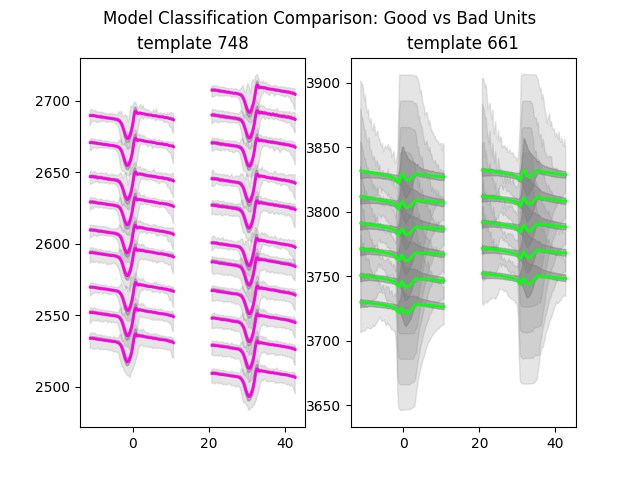

In [ ]:
# Identify representative units for visualization
good_units = labels[labels.iloc[:, 0] == 'good']
bad_units = labels[labels.iloc[:, 0] == 'bad']

# Find highest confidence examples of each class
if len(good_units) > 0:
    best_good_unit = good_units.iloc[:, 1].idxmax()
    good_confidence = good_units.loc[best_good_unit, good_units.columns[1]]
    print(f"Best 'good' unit: {best_good_unit} (confidence: {good_confidence:.1%})")

if len(bad_units) > 0:
    best_bad_unit = bad_units.iloc[:, 1].idxmax()
    bad_confidence = bad_units.loc[best_bad_unit, bad_units.columns[1]]
    print(f"Best 'bad' unit: {best_bad_unit} (confidence: {bad_confidence:.1%})")

# Plot template comparison
units_to_plot = []
if len(good_units) > 0:
    units_to_plot.append(best_good_unit)
if len(bad_units) > 0:
    units_to_plot.append(best_bad_unit)

if len(units_to_plot) >= 2:
    print(f"\nComparing templates for units {units_to_plot}")
    sw.plot_unit_templates(sorting_analyzer, unit_ids=units_to_plot)
    plt.suptitle("Model Classification Comparison: Good vs Bad Units")
    plt.show()
else:
    print("Only one class detected - plotting all available units")
    sw.plot_unit_templates(sorting_analyzer, unit_ids=sorting_analyzer.unit_ids[:4])
    plt.show()

### a.1 format of results 

## b. Bombcell

### b.1 format of results 

# 5. packaging

NWB: Neurodata without Borders

In [ ]:
def load_unit_data_phy(recording_path,chanmap=None,insertion_depth = 3840,insertion_angle = 0,timestamps_folder=None):
    cluster_info = pd.read_csv(os.path.join(recording_path, 'cluster_info.tsv'), sep='\t')
    if cluster_info.keys()[0]=='cluster_id':
        cluster_info = cluster_info.rename(columns={'cluster_id':'id'})
    spike_clusters = np.ndarray.flatten(np.load(os.path.join(recording_path, 'spike_clusters.npy')))
    spike_templates = np.load(open(os.path.join(recording_path,'spike_templates.npy'),'rb'))
    templates = np.load(open(os.path.join(recording_path,'templates.npy'),'rb'))
    spike_times = np.load(open(os.path.join(recording_path,'spike_times.npy'),'rb'))
    print(np.max(spike_times))

    try:
        timestamps = np.load(open(os.path.join(recording_path,'timestamps.npy'),'rb'))
    except: 
        print('searching folder tree for timestamps.npy')
        timestamps = np.load(open(os.path.join(timestamps_folder,'timestamps.npy'),'rb'))
    try:
        spike_secs = timestamps[spike_times.flatten()]
    except:
        print(np.shape(timestamps)[0])
        print(spike_times[-5:])
        spike_times_ = spike_times[spike_times < np.shape(timestamps)[0]]
        spike_secs = timestamps[spike_times_.flatten()]
        #to be added
        print(spike_secs.shape)
        spike_secs  = np.append(spike_secs, np.array([spike_secs[-1]] * np.shape(np.where(spike_times > np.shape(timestamps)[0])[0])[0]))
        print(spike_secs.shape)

    times = []
    mean_templates = []
    for unitID in cluster_info.id.values:
        times.append(spike_secs[spike_clusters == unitID])

        all_templates = spike_templates[np.where(spike_clusters==unitID)].flatten()
        if len(all_templates) > 100:
            n_templates_to_subsample = 100
        else: n_templates_to_subsample = len(all_templates)
        random_subsample_of_templates = templates[all_templates[np.array(np.random.rand(n_templates_to_subsample)*all_templates.shape[0]).astype(int)]]
        mean_template = np.mean(random_subsample_of_templates,axis=0)
        mean_templates.append(mean_template)
    cluster_info['times'] = times
    cluster_info['template'] = mean_templates
    cluster_info['depth_from_pia']=cluster_info.depth.values * -1 + insertion_depth*np.cos(np.deg2rad(insertion_angle))

    if chanmap is None:
        chanmap_json = os.path.join(recording_path, 'chanMap.json')
        if os.path.exists(chanmap_json):
            with open(chanmap_json, 'r') as f:
                chanmap = json.load(f)

                ycoords = np.asarray(chanmap['yc']).flatten()
                xcoords = np.asarray(chanmap['xc']).flatten()
        else:
            try:
                chanmap = loadmat(glob.glob(os.path.join(recording_path,'*hanMap.mat'))[0])
            except:
                chanmap = loadmat(glob.glob(os.path.join(os.path.dirname(recording_path),'*hanMap.mat'))[0])
                ycoords = np.asarray(chanmap['ycoords']).flatten()
                xcoords = np.asarray(chanmap['xcoords']).flatten()
    print(chanmap)


    cluster_info['ycoords'] = ycoords[cluster_info.ch.values]
    cluster_info['xcoords'] = xcoords[cluster_info.ch.values]
    cluster_info['shank'] = np.floor(cluster_info['xcoords'].values / 205.).astype(int)

    return cluster_info

### load kilosort/phy results

metadata

In [ ]:
probe_sn = '22456402431'
estimated_depth = 3300

In [ ]:
kilosort_folder = r'G:\MSIT\NPIX_MSIT_010\2026-04-10_10-05-01_NPIX_MSIT_010\kilosort4_output3\sorter_output'
cluster_info = load_unit_data_phy(kilosort_folder,
                                chanmap=None,
                                insertion_depth = estimated_depth,
                                insertion_angle = 10,
                                timestamps_folder = r'G:\MSIT\NPIX_MSIT_010\2026-04-10_10-05-01_NPIX_MSIT_010\Record Node 123\experiment1\recording1\continuous\OneBox-122.ProbeA-AP')
cluster_info['probe'] = [probe_sn]*cluster_info.shape[0]
df_units = cluster_info

39711344
searching folder tree for timestamps.npy


{'chanMap': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 21

In [ ]:
df_units.shape

(1011, 18)

(array([ 2.,  2.,  3.,  3., 11.,  3.,  7.,  5.,  7.,  9.]),
 array([ 129.86558494,  375.86558494,  621.86558494,  867.86558494,
        1113.86558494, 1359.86558494, 1605.86558494, 1851.86558494,
        2097.86558494, 2343.86558494, 2589.86558494]),
 <BarContainer object of 10 artists>)

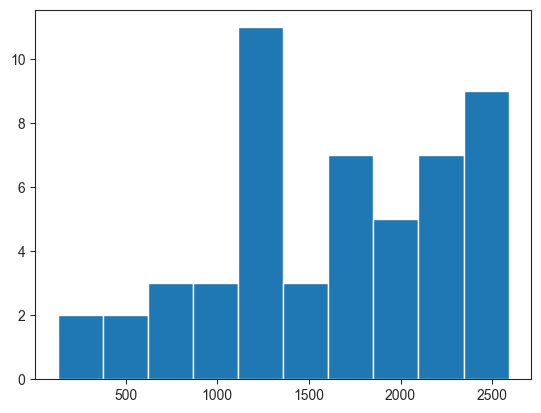

In [ ]:
plt.hist(df_units[df_units.group=='good'].depth_from_pia)

### load task information

In [ ]:
recording_folder = r'G:\MSIT\NPIX_MSIT_010\2026-04-10_10-05-01_NPIX_MSIT_010'
TTL_log_path = os.path.join(recording_folder,'NPX_MSIT_10_2026-04-10_10H_05m_02s_TTL_log.txt')
trial_log_path =  os.path.join(recording_folder,'NPX_MSIT_10_2026-04-10_10H_05m_02s_Trial_log.txt')
session = Session(recording_folder)

#match every TTL in the task info with a time on the npix clock (which is already synched across streams)
df_TTL = pd.read_table(TTL_log_path,delimiter='\s+')
events_df = pd.DataFrame(session.recordnodes[0].recordings[0].events)#
onebox_df = events_df[events_df.stream_name == 'OneBox-ADC' ]
task_events_df =onebox_df[(onebox_df.line==5)  &(onebox_df.state==1)]
task_events_df = task_events_df.iloc[-np.shape(df_TTL)[0]:,:]
df_TTL['npix_time']=np.array(task_events_df.timestamp)

# make sure every trial has an npix clock time for each event: Fixation Shown, Stimulus Shown, Response Recorded, and Trial Data Stored
df_trial = pd.read_table(trial_log_path,delimiter='\s+')

In [ ]:
df_trial

,Trial,Condition,Conflict,Stimulation,Stimuli,Correct,ISI,ResponseKey,ResponseAccuracy,ResponseUncertainty,ReactionTime
0,1,2,0,0,211,2,2.00,1,0,0.000069,1.704730
1,2,2,3,0,232,3,3.50,3,1,0.000422,3.671133
2,3,2,3,0,221,1,3.25,3,0,0.000476,3.237505
3,4,1,1,0,3,3,2.00,3,1,0.000070,2.361232
4,5,2,2,0,313,1,2.50,2,0,0.000246,1.823462
...,...,...,...,...,...,...,...,...,...,...,...
187,60,2,3,0,313,1,2.25,2,0,0.000077,2.512033
188,61,2,3,0,311,3,3.50,2,0,0.000429,1.785141
189,62,1,1,0,100,1,3.50,1,1,0.000070,1.095339
190,63,1,0,0,20,2,3.50,2,1,0.000076,1.033360


In [ ]:
 df_TTL

,Event,TTLTime,TimeFromStart,BlockNum,TrialNum,TTLEnabled,GoodForAlignment,TTLActuallySent,npix_time
0,TTL_Start_Train_01,3052.303848,0.005134,0,0,1,1,1,421.604993
1,TTL_Start_Train_02,3052.310305,0.011591,0,0,1,1,1,421.611428
2,TTL_Start_Train_03,3052.316715,0.018001,0,0,1,1,1,421.617830
3,TTL_Start_Train_04,3052.322904,0.024191,0,0,1,1,1,421.624001
4,TTL_Start_Train_05,3052.329129,0.030415,0,0,1,1,1,421.630238
...,...,...,...,...,...,...,...,...,...
792,Response_Key_Pressed,4281.991475,1229.692761,3,64,1,0,1,1651.278650
793,Trial_Data_Stored,4284.352732,1232.054018,3,64,1,1,1,1653.639759
794,Audio_Recording_Stopped,0.000000,-3052.298714,3,65,1,0,1,1655.655985
795,Saving_Data,4286.560816,1234.262102,3,65,1,1,1,1655.847879


In [ ]:
fixation_times, stimulus_times, response_times, trial_end_times = [],[],[],[]
if df_trial.shape[0] != df_TTL[df_TTL.Event=='Stimulus_Shown'].shape[0]: print('trial number does not match TTL data')
else:
    for i,row in df_trial.iterrows():
        stimulus_time = np.array(df_TTL[df_TTL.Event=='Stimulus_Shown'].npix_time)[i]
        trial_end = np.array(df_TTL[df_TTL.Event=='Trial_Data_Stored'].npix_time)[i]
        fixation_time = np.array(df_TTL[df_TTL.Event=='Fixation_Shown'].npix_time)[np.where(np.array(df_TTL[df_TTL.Event=='Fixation_Shown'].npix_time) < stimulus_time)[0][-1]]#;print(np.where(np.array(df_TTL[df_TTL.Event=='Fixation_Shown'].npix_time) < stimulus_time)[0][-1])
        response_time = np.array(df_TTL[df_TTL.Event=='Response_Key_Pressed'].npix_time)[np.argwhere(np.array(df_TTL[df_TTL.Event=='Response_Key_Pressed'].npix_time) > stimulus_time)[0][0]]
        fixation_times.append(fixation_time)
        stimulus_times.append(stimulus_time)
        response_times.append(response_time)
        trial_end_times.append(trial_end) 
    df_trial['fixaton_time'] = fixation_times
    df_trial['stimulus_time'] = stimulus_times
    df_trial['response_time'] = response_times
    df_trial['trial_end_time'] = trial_end_times


In [ ]:
df_trial

,Trial,Condition,Conflict,Stimulation,Stimuli,Correct,ISI,ResponseKey,ResponseAccuracy,ResponseUncertainty,ReactionTime,fixaton_time,stimulus_time,response_time,trial_end_time
0,1,2,0,0,211,2,2.00,1,0,0.000069,1.704730,530.943836,532.947753,534.652955,538.202355
1,2,2,3,0,232,3,3.50,3,1,0.000422,3.671133,534.702191,538.209714,541.880900,543.213402
2,3,2,3,0,221,1,3.25,3,0,0.000476,3.237505,539.963162,543.220431,546.458543,546.973935
3,4,1,1,0,3,3,2.00,3,1,0.000070,2.361232,544.973714,546.981228,549.343590,551.235885
4,5,2,2,0,313,1,2.50,2,0,0.000246,1.823462,548.735666,551.243145,553.066652,555.246656
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,60,2,3,0,313,1,2.25,2,0,0.000077,2.512033,1627.085442,1629.342501,1631.854994,1634.595898
188,61,2,3,0,311,3,3.50,2,0,0.000429,1.785141,1631.095733,1634.603818,1636.388946,1639.857233
189,62,1,1,0,100,1,3.50,1,1,0.000070,1.095339,1636.357002,1639.864163,1640.960004,1645.118187
190,63,1,0,0,20,2,3.50,2,1,0.000076,1.033360,1641.617956,1645.125117,1646.158838,1649.378570


### make NWB

In [ ]:
probes = [probe_sn]
locations = ['dlPFC']
descriptions = ['Neuropixels1.0-NHP-S'] 
device_name='starfix'
experimenter = 'djd drk'
experiment_description= 'Denman+Kramer Labs, University of Colorado Anschutz. Multi-source intererence task, dlPFC'

## a. create file 

In [ ]:
import pynwb
from hdmf.backends.hdf5.h5_utils import H5DataIO
from hdmf.utils import StrDataset

from datetime import datetime
from dateutil.tz import tzlocal
from pynwb import NWBFile

nwbfile = NWBFile('MSIT_dlPFC', 
                  recording_folder, 
                  datetime.now(tzlocal()),
                  experimenter=experimenter,
                  lab='Denman/Kramer Lab',
                  institution='University of Colorado',
                  experiment_description=experiment_description,
                  session_id=os.path.basename(recording_folder))


device = nwbfile.create_device(name=device_name)

for i, probe in enumerate(probes):
    electrode_name = 'probe'+str(i)
    description = descriptions[i]
    location = locations[i]

    electrode_group = nwbfile.create_electrode_group(electrode_name,
                                                     description=description,
                                                     location=location,
                                                     device=device)
    for ch in range(nwbtools.option234_positions.shape[0]):
        nwbfile.add_electrode(x=nwbtools.option234_positions[ch,0],y=0.,z=nwbtools.option234_positions[0,1],imp=0.0,location='none',filtering='high pass 300Hz',group=electrode_group)
    

## b. populate fields

In [ ]:
labels = {'noise':0,'mua':1,'good':2}

In [ ]:
# nwbfile.add_unit_column('location', 'the anatomical location of this unit')
# nwbfile.add_unit_column('quality', 'the quality for the inference of this unit')
# nwbfile.add_unit_column('quality_ISIviolations', 'the quality for the inference of this unit')
# nwbfile.add_unit_column('quality_sn', 'the quality for the inference of this unit')
# nwbfile.add_unit_column('quality_distance', 'the quality for the inference of this unit')

nwbfile.add_unit_column('depth', 'the depth of this unit from the pia')
nwbfile.add_unit_column('xpos', 'the x position on probe')
nwbfile.add_unit_column('ypos', 'the y position on probe')
# nwbfile.add_unit_column('template', 'Kilosort template')
nwbfile.add_unit_column('label', 'user label')
nwbfile.add_unit_column('KSlabel', 'Kilosort label')
nwbfile.add_unit_column('KSamplitude', 'Kilosort amplitude')
nwbfile.add_unit_column('KScontamination', 'Kilosort ISI contamination')
nwbfile.add_unit_column('probe', 'probe ID')
nwbfile.add_unit_column('channel', 'channel')
nwbfile.add_unit_column('n_spikes', 'number of spikes')
nwbfile.add_unit_column('amp', 'amp')
nwbfile.add_unit_column('shank', 'shank')

for i,unit_row in df_units[df_units.group=='good'].dropna().iterrows():
    if unit_row.group in labels.keys(): label=labels[unit_row.group]
    else: label=np.NaN
    nwbfile.add_unit(id=unit_row.id, 
                     spike_times=unit_row.times,
                     depth = unit_row.depth_from_pia,
                     xpos= unit_row.xcoords,
                     ypos= unit_row.ycoords,
                     waveform_mean=  utils.get_peak_waveform_from_template(unit_row.template)[:82],
                     label= unit_row.group,
                     KSlabel= labels[unit_row.KSLabel],
                     KSamplitude= unit_row.Amplitude,
                     KScontamination= unit_row.ContamPct,
                     probe= unit_row.probe,
                    channel= unit_row.ch,
                    n_spikes= unit_row.n_spikes,
                    amp= unit_row.amp,
                    shank = unit_row.shank
                    )

In [ ]:
for i,block_start in enumerate(df_TTL[df_TTL.Event=='Initializing_Block'].npix_time):
    print(block_start)
    if i+1 < df_TTL[df_TTL.Event=='Initializing_Block'].shape[0]:
        nwbfile.add_epoch(block_start, 
                          np.array(df_TTL[df_TTL.Event=='Initializing_Block'].npix_time)[i+1],
                        ['block_'+str(i+1)])
    else:
        nwbfile.add_epoch(block_start, 
                    np.array(df_TTL.npix_time)[-1]+5.,#last TTL + some buffer
                ['block_'+str(i+1)])

521.4090371368285
904.6845907696664
1344.5456805053059


In [ ]:
for co in df_trial.columns:
    nwbfile.add_trial_column(co, co)

for trial,row in df_trial.iterrows():
    nwbfile.add_trial(start_time=row.fixaton_time, 
                      stop_time=row.trial_end_time, 
                      Stimuli=int(row.Stimuli),
                    Trial=row.Trial,
                    Condition=int(row.Condition),
                    Conflict=int(row.Conflict),
                    Stimulation=row.Stimulation,
                    Correct=int(row.Correct),
                    ISI=row.ISI,
                    ResponseKey=int(row.ResponseKey),
                    ResponseAccuracy=row.ResponseAccuracy,
                    ResponseUncertainty=row.ResponseUncertainty,
                    ReactionTime=row.ReactionTime,
                    fixaton_time=row.fixaton_time,
                    stimulus_time=row.stimulus_time,
                    response_time=row.response_time,
                    trial_end_time=row.trial_end_time,
                     )

## c. write and close

In [ ]:
nwb_path = os.path.join(recording_folder,'NPIX_MSIT_010_filteredUnits.nwb')
with pynwb.NWBHDF5IO(nwb_path, 'w') as io:
    io.write(nwbfile)